In [1]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
import matplotlib

In [2]:
def get_var_size():
    # Get all variables in the current namespace
    variables = {name: value for name, value in globals().items() if not name.startswith("__")}

    # Sort variables by size
    sorted_vars = sorted(variables.items(), key=lambda x: sys.getsizeof(x[1]), reverse=True)

    # Print variable sizes
    for name, value in sorted_vars:
        print(f"{name}: {sys.getsizeof(value) / 1024:.2f} KB")

In [3]:
%%time
fly_list=[226,227,228,234,239,240,241,242,249,250] #choose flies off which to create the supervox mask--try using all
# fly_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly_num}'
# filter_name = 'functional_channel_2_moco_warp_blurred_hpf_dff_filtered_total.h5'
# STA_path = os.path.join(fly_path, 'temp_filter', filter_name)
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
# step_size=100
# for fly in fly_list:
#     fly_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly}'
#     files = os.listdir(os.path.join(fly_path, 'temp_filter'))
#     file = f"functional_channel_2_moco_warp_blurred_hpf_dff_filtered_total.h5"
#     if file in files:
#         source = os.path.join(fly_path, 'temp_filter', file)
#         new_file = f"{fly}_tf_total.h5"
#     #         print(new_file)
#         destination = os.path.join(later_dir, new_file)
#         if os.path.exists(destination)==False: 
#             dest = shutil.copyfile(source, destination)
#             print("Destination path:", destination)

#     else:
#         print("Not there yet!")
    

CPU times: user 2 µs, sys: 3 µs, total: 5 µs
Wall time: 9.3 µs


In [4]:
fly_list

[226, 227, 228, 234, 239, 240, 241, 242, 249, 250]

In [5]:
# %%time
# ####INTERLEAVE the filtered voxels--there might be an easier way to do this or that it's not necessary but 
# # idk what that is. Feel free to find your own way.
# nx,ny,nz,nt=314,146, 91, 1100
# # nt is a value based of the largest of my tf files last dimmension. I wasn't sure how best to establish so 
# # i hard coded here. I know, bad practice.
# final_nt=len(fly_list) * nt
# interleaved = np.empty((nx * ny * nz, final_nt), dtype=np.float32)
# print(f"inter shape is {np.shape(interleaved)}")
# for i, fly in enumerate(fly_list):
#     print(fly)
#     file_name = f"{fly}_tf_total.h5"
#     tf_path = os.path.join(later_dir,file_name)
#     if os.path.exists(tf_path):
#         with h5py.File(tf_path, 'r') as hf:
#                 brain = hf['brain'][:]
#                 dimsb = np.shape(brain)
#                 print(f"Brain shape is {dimsb}")
#                 padded_matrix = np.pad(brain, ((0, 0), (0, 0), (0, 0), (0, nt - dimsb[-1])), mode='constant', constant_values=np.nan)
#                 reshaped_matrix = padded_matrix.reshape(nx * ny * nz, nt)
#                 interleaved[:, i::len(fly_list)] = reshaped_matrix
# interleaved_4d = interleaved.reshape(nx, ny, nz, final_nt)
# print(np.shape(interleaved_4d))

In [6]:
# %%time
# save_file=os.path.join(later_dir, "10flies_giant_tf.npy")
# with h5py.File(save_file, "w") as data_file:
#     data_file.create_dataset("data", data=interleaved_4d.astype('float32'))

In [7]:
%%time
load_file=os.path.join(later_dir, "10flies_giant_tf.npy")
with h5py.File(load_file, 'r') as hf:
    interleaved_4d = hf['data'][:]
    dimsb = np.shape(interleaved_4d)
    print(f"Brain shape is {dimsb}")

Brain shape is (314, 146, 91, 11000)
CPU times: user 19.2 ms, sys: 1min 24s, total: 1min 24s
Wall time: 13min 15s


In [8]:
# %%time
# # there were some weird values in my brains (probs just imaging bugs). I tried nan_to_num to get rid of those
# # vals but it was too time intensive so this essentially removes them

# interleaved_4d[np.isnan(interleaved_4d)] = 0
# interleaved_4d[np.isinf(interleaved_4d)] = 5

In [9]:
# %%time
### Here's as mentioned above
# save_file=os.path.join(later_dir, "10flies_giant_tf.npy")
# dims=np.shape(interleaved_4d)
# steps=1000
# with h5py.File(save_file, 'w') as f:
# #     f.create_dataset('dims', data=dims)
#     dset = f.create_dataset('data', dims, dtype='float32', chunks=True)
    
#     for i in range(0,dims[-1],steps):
#         end = i + steps if i + steps < dims[-1] else dims[-1]
#         print(i, end)
#         f['data'][:,:,:,i:end] = np.nan_to_num(interleaved_4d[...,i:end])

In [10]:
# %%time
# warnings.filterwarnings("ignore", category=RuntimeWarning)
# warnings.filterwarnings("ignore", category=UserWarning)
# cluster_dir = os.path.join(later_dir, 'clustering')
# if not os.path.exists(cluster_dir):
#     os.mkdir(cluster_dir)
# n_clusters = 2000
# brain=interleaved_4d
# shape=np.shape(brain)
# connectivity = grid_to_graph(shape[0],shape[1])
# cluster_labels = []
# t_shape = shape[3]
# for z in range(shape[2]):
#     neural_activity = brain[:,:,z,:].reshape(-1, t_shape)
#     cluster_model = AgglomerativeClustering(n_clusters=n_clusters,
#                                 memory=cluster_dir,
#                                 linkage='ward',
#                                 connectivity=connectivity)
#     cluster_model.fit(neural_activity)
#     cluster_labels.append(cluster_model.labels_)
# cluster_labels = np.asarray(cluster_labels)

In [11]:
# cluster_labels = np.asarray(cluster_labels)
# save_file = os.path.join(cluster_dir, '10flies_cluster_labels_best_flies.npy')
# np.save(save_file,cluster_labels)
# print(np.shape(cluster_labels))

In [12]:
cluster_dir = os.path.join(later_dir, 'clustering')
load_file=os.path.join(cluster_dir, '10flies_cluster_labels_best_flies.npy')
cluster_labels=np.load(load_file)
print(np.shape(cluster_labels))

(91, 45844)


In [13]:
rainbow_color=np.asarray(['#FFFFFF','#EF476F', '#F78C6B', '#FFD166', '#06D6A0','#118AB2','#6A4C93','#6d0d25']) #,  '#6d0d25'
# cmap_rainbow = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'cmap', rainbow_color)
cmap_rainbow = matplotlib.colors.ListedColormap(rainbow_color)

In [14]:
cluster_labels_anat=cluster_labels.reshape(91,314,146,)

(-0.5, 313.5, 145.5, -0.5)

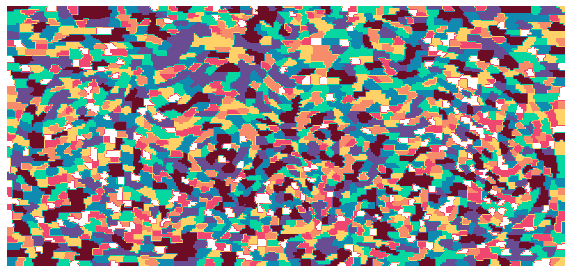

In [15]:
z=33
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(cluster_labels_anat[z].T, cmap=cmap_rainbow)
plt.axis('off')

In [16]:
%%time
brain=interleaved_4d
shape=np.shape(brain)
t_shape = shape[3]
n_clusters = 2000
all_signals = []
for z in range(shape[2]):
    neural_activity = brain[:,:,z,:].reshape(-1, t_shape)
    signals = []
    for cluster_num in range(n_clusters):
        cluster_indicies = np.where(cluster_labels[z,:]==cluster_num)[0]
        mean_signal = np.mean(neural_activity[cluster_indicies,:], axis=0)
        signals.append(mean_signal)
    signals = np.asarray(signals)
    all_signals.append(signals)
all_signals = np.asarray(all_signals)

CPU times: user 30.3 s, sys: 7.97 s, total: 38.3 s
Wall time: 38.3 s


In [17]:
all_signals.shape

(91, 2000, 11000)

In [22]:
signals=np.moveaxis(all_signals[...,:500], -1,1)

In [23]:
%%time
supervox_brain=signals
full_res_brain=brainsss.supervoxel_to_full_res(supervox_brain, cluster_labels, n_clusters)
# full_res_brain=np.moveaxis(full_res_brain, 0,-1)
# full_res_brain=np.moveaxis(full_res_brain, 0,-1)
full_res=np.asarray(full_res_brain)

CPU times: user 32.1 s, sys: 8.92 s, total: 41 s
Wall time: 41 s


In [25]:
print(full_res.shape)
full_res=np.moveaxis(full_res, 1, -1)
print(full_res.shape)

(91, 500, 314, 146)


In [27]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

In [31]:
interleaved_4d.shape

(314, 146, 91, 11000)

(-0.5, 313.5, 145.5, -0.5)

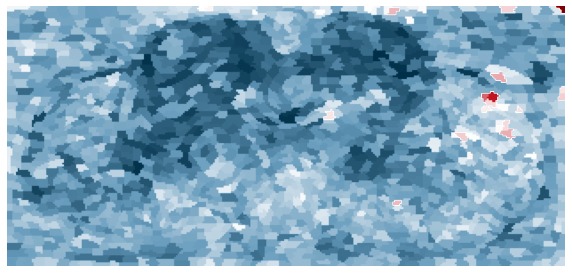

In [37]:
z=33
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(np.nanmax(full_res[z], axis=-1).T, cmap=cmap_personal)
plt.axis('off')